# **TUGAS 2**

# **penjelasan outlier deteksi**

## **Deteksi Outlier dengan K-Nearest Neighbors  (KNN) dalam Data Understanding**

# 1. apa itu outlier deteksi?

Outlier detection atau deteksi outlier adalah proses mengidentifikasi data yang memiliki nilai yang sangat berbeda dari mayoritas data lainnya dalam suatu dataset. Outlier sering kali disebabkan oleh kesalahan pengukuran, anomali sistem, atau memang fenomena yang jarang terjadi.

# 2. mengapa KNN bisa digunakan untuk deteksi outlier?

K-Nearest Neighbors (KNN) bisa digunakan untuk deteksi outlier karena metode ini mengukur jarak antara titik data satu dengan yang lain. Outlier biasanya memiliki jarak yang jauh dari tetangga terdekatnya dibandingkan dengan titik data normal yang berada dalam kelompok yang lebih padat.

# 3. Langkah-Langkah Deteksi Outlier dengan KNN

1. Menghitung Jarak ke K Tetangga Terdekat Untuk setiap titik data, KNN menghitung jarak ke sejumlah K tetangga terdekatnya.
2. Menentukan Skor Outlier Jika suatu titik memiliki jarak rata-rata ke K tetangga terdekat yang jauh lebih besar dibandingkan titik lainnya, maka titik tersebut kemungkinan adalah outlier.
3. Menentukan Threshold Setelah mendapatkan skor jarak untuk setiap titik, kita dapat menetapkan threshold untuk mendeteksi outlier. Misalnya, jika jarak rata-rata ke tetangga melebihi batas tertentu, maka titik tersebut dianggap outlier.

# 4. Kelebihan dan Kekurangan Metode KNN untuk Deteksi Outlier

***1. Kelebihan KNN untuk Deteksi Outlier Non-parametrik ***

- KNN tidak mengasumsikan distribusi tertentu dari data, sehingga cocok untuk berbagai jenis dataset.
Dapat digunakan untuk data dengan berbagai dimensi

- Cocok untuk data berdimensi tinggi maupun rendah.
Mudah diimplementasikan

- Algoritma KNN cukup sederhana dan dapat dengan mudah diterapkan menggunakan pustaka seperti scikit-learn.
Fleksibel terhadap berbagai jenis data

- Bisa digunakan untuk data numerik, kategorikal, atau gabungan keduanya.
Cocok untuk dataset dengan pola klaster

- KNN dapat dengan baik mengidentifikasi outlier yang jauh dari klaster utama data.

**2. Kekurangan KNN untuk Deteksi Outlier**

- Biaya komputasi tinggi

- Untuk dataset besar, menghitung jarak ke setiap titik data lainnya bisa sangat mahal dan lambat.
Sulit memilih nilai K yang optimal

- Jika K terlalu kecil, algoritma bisa menjadi terlalu sensitif terhadap noise.
Jika K terlalu besar, bisa gagal mendeteksi beberapa outlier.
Kurang efektif jika distribusi outlier tidak jelas

- Jika outlier tidak memiliki jarak yang signifikan dari data lain, metode ini bisa gagal mengenalinya.
Tergantung pada metrik jarak yang digunakan

- Kinerja KNN dapat bervariasi tergantung pada apakah menggunakan Euclidean, Manhattan, atau metrik lainnya.
Kurang efisien pada data berdimensi tinggi

- Dalam dimensi yang sangat tinggi (curse of dimensionality), perhitungan jarak menjadi kurang berarti karena semua titik tampak hampir sama jauhnya.

# 5. Kesimpulan

Metode K-Nearest Neighbors (KNN) untuk deteksi outlier bekerja dengan mengukur jarak suatu titik data terhadap tetangga terdekatnya. Jika jarak tersebut jauh dibandingkan dengan data lain, maka titik tersebut dianggap sebagai outlier.

✅ Kelebihan KNN untuk deteksi outlier adalah fleksibilitasnya terhadap berbagai jenis data, tidak memerlukan asumsi distribusi, serta kemampuannya dalam mengidentifikasi outlier di dataset dengan pola klaster.

❌ Kekurangannya meliputi biaya komputasi yang tinggi, kesulitan dalam memilih nilai K yang optimal, serta keterbatasan dalam menangani data berdimensi tinggi atau dataset dengan distribusi outlier yang tidak jelas.

Secara keseluruhan, KNN merupakan metode yang baik untuk deteksi outlier dalam dataset yang relatif kecil hingga menengah dengan pola klaster yang jelas. Namun, untuk dataset besar atau berdimensi tinggi, metode lain seperti Isolation Forest atau DBSCAN

In [1]:
%pip install pymysql
%pip install psycopg2


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Perintah tersebut digunakan untuk menginstal pustaka Python yang memungkinkan koneksi ke database.

- pymysql digunakan untuk berkomunikasi dengan database MySQL, memungkinkan Python menjalankan perintah SQL seperti mengambil, menyimpan, atau menghapus data.
psycopg2 berfungsi serupa, tetapi khusus untuk database PostgreSQL.

 id           class  petal_length  petal_width  sepal_length  sepal_width  distance  outlier
  1     Iris-setosa           1.4          0.2           5.1          3.5  5.424942    False
  2     Iris-setosa          14.0          2.0          40.9         30.0 46.407542     True
  3     Iris-setosa           1.3          0.2           4.7          3.2  5.430470    False
  4     Iris-setosa           1.5          0.2           4.6          3.1  5.273519    False
  5     Iris-setosa           1.4          0.2           5.0          3.6  5.485435     True
  6     Iris-setosa           1.7          0.4           5.4          3.9  5.288667    False
  7     Iris-setosa           1.4          0.3           4.6          3.4  5.412947    False
  8     Iris-setosa           1.5          0.2           5.0          3.4  5.325411    False
  9     Iris-setosa           1.4          0.2           4.4          2.9  5.316014    False
 10     Iris-setosa           1.5          0.1           4.9          

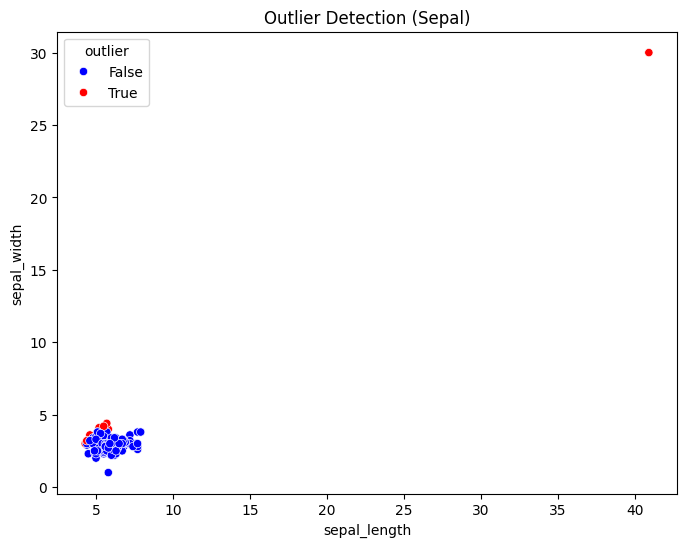

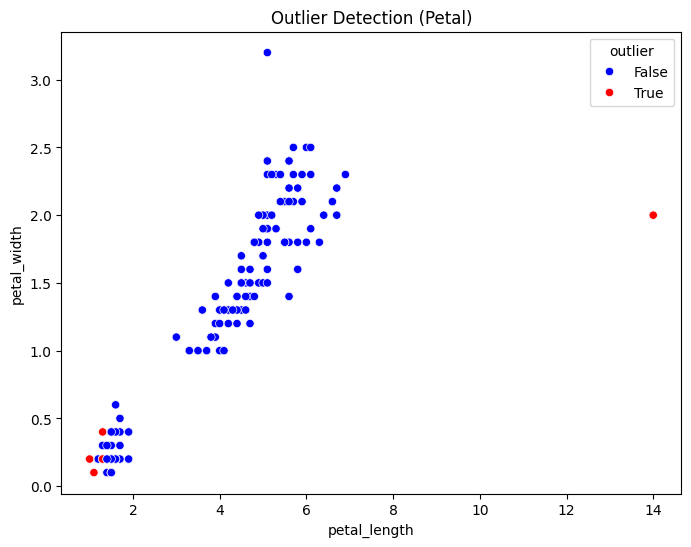

In [2]:
import psycopg2
import pymysql
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

def get_pg_data():
    conn = psycopg2.connect(
        host="pg-1c79828e-posgressqlpendata.i.aivencloud.com",
        user="avnadmin",
        password="AVNS_lNd8P_-IyQzpcnKg3Ye",
        database="defaultdb",
        port=14572
    )
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM bunga")
    data = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]
    cursor.close()
    conn.close()
    return pd.DataFrame(data, columns=columns)

def get_mysql_data():
    conn = pymysql.connect(
        host="mysql-3f95b8aa-mysqll.g.aivencloud.com",
        user="avnadmin",
        password="AVNS_DYTBfDjLFuF2XVSXIqF",
        database="flowers_mysql",
        port=12288
    )
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM flowermysql")
    data = cursor.fetchall()
    columns = [desc[0] for desc in cursor.description]
    cursor.close()
    conn.close()
    return pd.DataFrame(data, columns=columns)

# Ambil data dari kedua database
df_postgresql = get_pg_data()
df_mysql = get_mysql_data()

# Gabungkan berdasarkan kolom 'id' dan 'Class'
df_merged = pd.merge(df_mysql, df_postgresql, on=["id", "class"], how="inner")

# Ambil data fitur numerik
feature_columns = ["petal_length", "petal_width", "sepal_length", "sepal_width"]
data_values = df_merged[feature_columns].values

# Ambil referensi dari baris terakhir (baris ke-152 jika dihitung dari 1, atau index -1)
reference_point = data_values[-1]

def compute_distances(data, reference):
    return np.array([euclidean(row, reference) for row in data])

# Hitung jarak Euclidean dari setiap baris ke referensi
df_merged["distance"] = compute_distances(data_values, reference_point)

# Tentukan threshold outlier berdasarkan persentil ke-95 (bisa disesuaikan)
threshold = np.percentile(df_merged["distance"], 93.5)
df_merged["outlier"] = df_merged["distance"] > threshold

# Cetak hasil data dengan outlier
print(df_merged.to_string(index=False))

# Visualisasi scatter plot dengan warna berdasarkan outlier
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_merged["sepal_length"], y=df_merged["sepal_width"],
    hue=df_merged["outlier"], palette={False: "blue", True: "red"}
)
plt.title("Outlier Detection (Sepal)")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_merged["petal_length"], y=df_merged["petal_width"],
    hue=df_merged["outlier"], palette={False: "blue", True: "red"}
)
plt.title("Outlier Detection (Petal)")
plt.show()


🛠 Tahapan Eksekusi:

1️⃣ Mengambil Data dari Database
- Data diambil dari PostgreSQL (tabel bunga) dan MySQL (tabel flowermysql).
- Data dikonversi ke dalam format DataFrame Pandas agar lebih mudah diolah.

2️⃣ Menggabungkan Data
- Penggabungan dilakukan berdasarkan kolom "id" dan "class".
- Hanya data yang cocok dari kedua database yang digunakan untuk analisis.

3️⃣ Menyiapkan Data untuk Analisis
- Fitur numerik yang dianalisis meliputi panjang dan lebar petal serta sepal.
- Data dikonversi ke dalam array NumPy untuk perhitungan jarak.

4️⃣ Menghitung Jarak Euclidean
- Referensi outlier diambil dari baris terakhir dataset.
- Jarak Euclidean dihitung antara setiap baris data dengan referensi.
- Hasil perhitungan disimpan dalam kolom baru "distance".

5️⃣ Menentukan Outlier
- Threshold outlier ditentukan berdasarkan persentil ke-93.5% dari nilai jarak.
- Jika jarak suatu data melebihi threshold, maka ditandai sebagai outlier (True), jika tidak, sebagai normal (False).
- Hasilnya disimpan dalam kolom "outlier".

6️⃣ Menampilkan dan Memvisualisasikan Data
- Tabel hasil analisis ditampilkan dengan tambahan informasi jarak dan status outlier.
- Scatter plot digunakan untuk memperlihatkan persebaran data dengan:
- Sepal (panjang vs lebar)
- Petal (panjang vs lebar)
- Outlier diberi warna merah, sedangkan data normal berwarna biru.


In [3]:
# Hitung total outlier
total_outliers = df_merged["outlier"].sum()
print(f"Total Outlier: {total_outliers}")

Total Outlier: 10


🛠 Cara Kerja:
1. Menggunakan kolom "outlier"
Setiap baris data memiliki status outlier yang bernilai True (outlier) atau False (normal).
2. Menjumlahkan total outlier
Karena nilai True dihitung sebagai 1 dan False sebagai 0, maka jumlah total outlier dapat diperoleh dengan menjumlahkan kolom ini.
3. Menampilkan hasil
Jumlah total outlier ditampilkan untuk mengetahui seberapa banyak data yang dianggap menyimpang.

In [4]:
# Urutkan data berdasarkan jarak dari terkecil ke terbesar
df_sorted = df_merged.sort_values(by="distance", ascending=True)

# Tampilkan hasilnya
print(df_sorted.to_string(index=False))

 id           class  petal_length  petal_width  sepal_length  sepal_width  distance  outlier
151            ????           5.1          3.2           5.8          1.0  0.000000    False
114  Iris-virginica           5.0          2.0           5.7          2.5  1.926136    False
115  Iris-virginica           5.1          2.4           5.8          2.8  1.969772    False
147  Iris-virginica           5.0          1.9           6.3          2.5  2.049390    False
120  Iris-virginica           5.0          1.5           6.0          2.2  2.092845    False
143  Iris-virginica           5.1          1.9           5.8          2.7  2.140093    False
102  Iris-virginica           5.1          1.9           5.8          2.7  2.140093    False
122  Iris-virginica           4.9          2.0           5.6          2.8  2.181742    False
133  Iris-virginica           5.6          2.2           6.4          2.8  2.202272    False
 69 Iris-versicolor           4.5          1.5           6.2          

🛠 Cara Kerja:
1. Mengurutkan berdasarkan kolom "distance"

Setiap baris dalam dataset memiliki nilai jarak (distance) terhadap titik referensi.
Data diurutkan dari jarak terkecil (paling mirip dengan referensi) hingga terbesar (paling jauh dari referensi).
2. Mengidentifikasi pola dalam data

Data dengan jarak kecil umumnya lebih mirip dengan mayoritas data lainnya.
Data dengan jarak besar berpotensi sebagai outlier atau anomali.
3. Menampilkan hasil pengurutan

Setelah diurutkan, data ditampilkan agar dapat dianalisis lebih lanjut.